In [1]:
import h5py
import matplotlib.pyplot as plt	

ORIGINAL_DATASET_PATH = "./ani1x-release.h5"

f =  h5py.File(ORIGINAL_DATASET_PATH, "r") 

# Keys represent different molecules groups.
print("Different molecules:",len(f.keys()), f.keys())
# Each molecule group contains data such as atomic numbers, coordinates, ecc for a number of conformations.
print("Keys for each molecule:",f['C10H10'].keys())
# The number of atomic numbers is the number of atoms
print("Example of atomic numbers:",len(f['C10H10']['atomic_numbers'][()]), f['C10H10']['atomic_numbers'][()])
# The number of coordinates is the number of conformations, and each conformation has a coordinate for each atom.
print("Shape of coordinates:",(f['C10H10']['coordinates'][()]).shape)
# The number of energy labels is the number of conformations, 1 for each conformation.
print("Shape of energy labels:",(f['C10H10']['ccsd(t)_cbs.energy'][()]).shape)
# The shape of forces is 3 coordinates per atom.
print("Shape of forces labels:",(f['C10H10']['wb97x_dz.forces'][()]).shape)

f.close()


Different molecules: 3114 <KeysViewHDF5 ['C10H10', 'C10H10N2', 'C10H10N2O1', 'C10H10N2O2', 'C10H10N4', 'C10H10N4O1', 'C10H10N4O2', 'C10H10O1', 'C10H10O2', 'C10H10O3', 'C10H10O4', 'C10H10O5', 'C10H11N1', 'C10H11N1O1', 'C10H11N1O2', 'C10H11N1O3', 'C10H11N3', 'C10H11N3O1', 'C10H11N3O2', 'C10H11N5', 'C10H12', 'C10H12N2', 'C10H12N2O1', 'C10H12N2O2', 'C10H12N2O3', 'C10H12N2O4', 'C10H12N4', 'C10H12N4O1', 'C10H12N4O2', 'C10H12N6', 'C10H12O1', 'C10H12O2', 'C10H12O3', 'C10H12O4', 'C10H13N1', 'C10H13N1O1', 'C10H13N1O2', 'C10H13N1O3', 'C10H13N1O4', 'C10H13N3', 'C10H13N3O1', 'C10H13N3O2', 'C10H13N5', 'C10H13N5O1', 'C10H14', 'C10H14N2', 'C10H14N2O1', 'C10H14N2O2', 'C10H14N2O3', 'C10H14N2O4', 'C10H14N4', 'C10H14N4O1', 'C10H14N4O2', 'C10H14N4O3', 'C10H14N4O5', 'C10H14N6', 'C10H14O1', 'C10H14O2', 'C10H14O3', 'C10H14O4', 'C10H14O5', 'C10H15N1', 'C10H15N1O1', 'C10H15N1O2', 'C10H15N1O3', 'C10H15N1O4', 'C10H15N3', 'C10H15N3O1', 'C10H15N3O2', 'C10H15N5', 'C10H15N5O1', 'C10H15N5O4', 'C10H15N5O5', 'C10H16', '

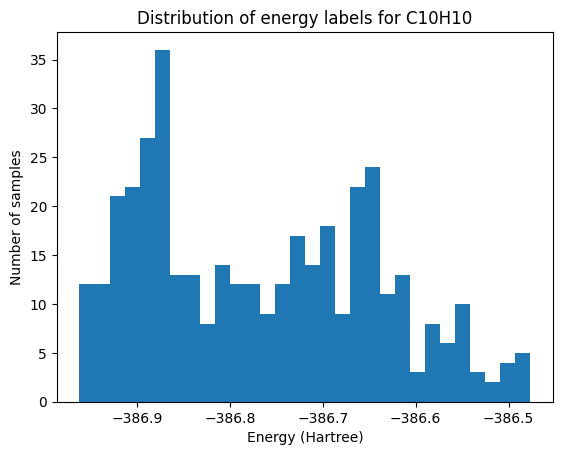

In [4]:
# for the molecule C10H10 plot the distributon of the energy labels.
energy_labels = f['C10H10']['wb97x_dz.energy'][()]
# print(len(energy_labels), energy_labels)
plt.hist(energy_labels, bins=30)
plt.xlabel("Energy (Hartree)")
plt.ylabel("Number of samples")
plt.title("Distribution of energy labels for C10H10")
plt.show()

Mean number of atoms: 23.36223506743738
Median number of atoms: 23
Min number of atoms: 2
Max number of atoms: 63
Std of number of atoms: 9.868685006223744


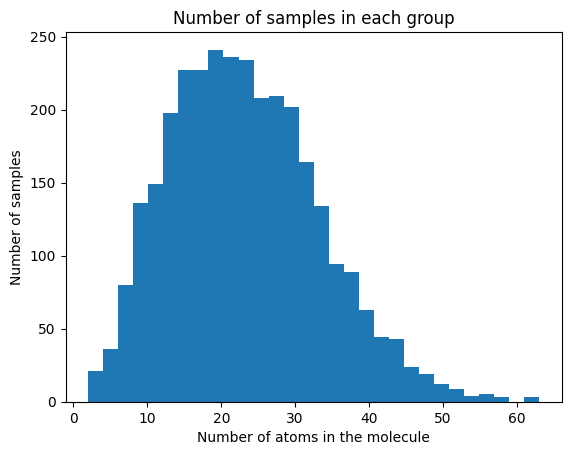

In [3]:
import h5py
import matplotlib.pyplot as plt	

f =  h5py.File(ORIGINAL_DATASET_PATH, "r") 

num_of_atoms = []
for group in f.keys():
	el_in_group = len(f[group]["atomic_numbers"][()])
	num_of_atoms.append(el_in_group)

# mean, median, min, max, std of num_of_atoms
print("Mean number of atoms:", sum(num_of_atoms)/len(num_of_atoms))
print("Median number of atoms:", sorted(num_of_atoms)[len(num_of_atoms)//2])
print("Min number of atoms:", min(num_of_atoms))
print("Max number of atoms:", max(num_of_atoms))
print("Std of number of atoms:", (sum([(x - sum(num_of_atoms)/len(num_of_atoms))**2 for x in num_of_atoms])/len(num_of_atoms))**0.5)

plt.hist(num_of_atoms, bins=30)
plt.xlabel("Number of atoms in the molecule")
plt.ylabel("Number of samples")
plt.title("Number of samples in each group")
plt.show()

Total number of samples in the dataset: 4956005
Mean number of configurations: 1591.523763648041
Median number of configurations: 134
Min number of configurations: 1
Max number of configurations: 59141
Std of number of configurations: 4866.251822684417


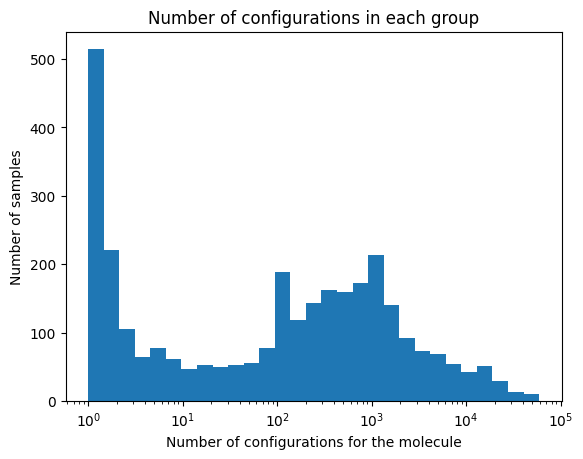

In [5]:
import numpy as np
num_of_configs = []
for group in f.keys():
	configs_in_group = (f[group]['coordinates'][()]).shape[0]
	num_of_configs.append(configs_in_group)

# remove outliers for better visualization
# num_of_configs = [x for x in num_of_configs if x > 25]

# Total number of samples in the dataset is the sum of the number of configurations across all groups.
total_samples = sum(num_of_configs)
print("Total number of samples in the dataset:", total_samples)

# mean, median, min, max, std of num_of_atoms
print("Mean number of configurations:", sum(num_of_configs)/len(num_of_configs))
print("Median number of configurations:", sorted(num_of_configs)[len(num_of_configs)//2])
print("Min number of configurations:", min(num_of_configs))
print("Max number of configurations:", max(num_of_configs))
print("Std of number of configurations:", (sum([(x - sum(num_of_configs)/len(num_of_configs))**2 for x in num_of_configs])/len(num_of_configs))**0.5)


plt.hist(num_of_configs, bins=np.logspace(0, np.log10(max(num_of_configs)), 30))
plt.xlabel("Number of configurations for the molecule")
plt.ylabel("Number of samples")
# LOGSCALE
# plt.yscale("log")
plt.xscale("log")
plt.title("Number of configurations in each group")
plt.show()



In [1]:

!python build_ani1x_extxyz.py --h5 ani1x-release.h5 --outdir mace_xyz \
	--n-train 20000 --n-val 2000 --n-test 5000 \
	--max-per-compound 200 \
	--energy-key "wb97x_dz.energy" --forces-key "wb97x_dz.forces" \
	--exclusive-compounds \
	--seed 0


Wrote:
  mace_xyz/train.xyz
  mace_xyz/val.xyz
  mace_xyz/test.xyz
  mace_xyz/manifest.csv

Canonical keys:
  energy: 'wb97x_dz.energy' -> "energy" (if provided and present)
  forces: 'wb97x_dz.forces' -> "forces" (if provided and present)


In [6]:
from ani1x_annotation_coverage import summarize_annotation_coverage

ORIGINAL_DATASET_PATH = "./ani1x-release.h5"


theory_keys = [
    'ccsd(t)_cbs.energy',
    'hf_dz.energy', 'hf_tz.energy', 'hf_qz.energy',
    'mp2_dz.corr_energy', 'mp2_tz.corr_energy', 'mp2_qz.corr_energy',
    'npno_ccsd(t)_dz.corr_energy', 'npno_ccsd(t)_tz.corr_energy', 'tpno_ccsd(t)_dz.corr_energy',
    'wb97x_dz.energy', 'wb97x_tz.energy',
]

coverage = summarize_annotation_coverage(ORIGINAL_DATASET_PATH, theory_keys=theory_keys)
summary = coverage.summary.copy()
for column in ['system_fraction', 'valid_config_fraction', 'dataset_fraction_overall']:
    summary[column] = (100.0 * summary[column]).round(2)

display(summary)

focus_key = 'ccsd(t)_cbs.energy'
focus = coverage.system_details[coverage.system_details['theory_key'] == focus_key].copy()
print(f"{focus_key}: {int(focus['valid_configs'].sum())} annotated configurations across {(focus['valid_configs'] > 0).sum()} systems.")
print(
    f"Full-system coverage: {(focus['coverage_type'] == 'all').sum()} | "
    f"partial-system coverage: {(focus['coverage_type'] == 'partial').sum()} | "
    f"systems with no finite labels: {(focus['coverage_type'] == 'none').sum()}"
)

display(
    focus[focus['coverage_type'] != 'none']
    .sort_values(['coverage_fraction', 'valid_configs', 'system'])
    .head(200)
)

# save the focus df

focus[focus['coverage_type'] != 'none'] \
	.sort_values(['valid_configs', 'coverage_fraction', 'system'], ascending=[False, False, True]) \
	.to_csv("ani1x_ccsdt_cbs_energy_coverage.csv", index=False)


# Change focus_key to inspect another level of theory, e.g. 'wb97x_tz.energy'.


,theory_key,systems_with_dataset,systems_with_any_valid_configs,systems_with_all_configs_valid,systems_with_partial_configs_valid,systems_with_zero_valid_configs,configs_in_present_systems,valid_configs,system_fraction,valid_config_fraction,dataset_fraction_overall
0,wb97x_dz.energy,3114,3114,3114,0,0,4956005,4956005,100.0,100.00,100.00
1,wb97x_tz.energy,3114,2418,560,1858,696,4956005,4617229,100.0,93.16,93.16
2,ccsd(t)_cbs.energy,3114,1910,21,1889,1204,4956005,489571,100.0,9.88,9.88
3,hf_dz.energy,3114,1910,21,1889,1204,4956005,489571,100.0,9.88,9.88
4,hf_qz.energy,3114,1910,21,1889,1204,4956005,489571,100.0,9.88,9.88
5,hf_tz.energy,3114,1910,21,1889,1204,4956005,489571,100.0,9.88,9.88
6,mp2_dz.corr_energy,3114,1910,21,1889,1204,4956005,489571,100.0,9.88,9.88
7,mp2_qz.corr_energy,3114,1910,21,1889,1204,4956005,489571,100.0,9.88,9.88
8,mp2_tz.corr_energy,3114,1910,21,1889,1204,4956005,489571,100.0,9.88,9.88
9,npno_ccsd(t)_dz.corr_energy,3114,1910,21,1889,1204,4956005,489571,100.0,9.88,9.88


ccsd(t)_cbs.energy: 489571 annotated configurations across 1910 systems.
Full-system coverage: 21 | partial-system coverage: 1889 | systems with no finite labels: 1204


,theory_key,system,n_configs,valid_configs,missing_configs,coverage_fraction,coverage_type
1225,ccsd(t)_cbs.energy,C13H20O2,384,1,383,0.002604,partial
1226,ccsd(t)_cbs.energy,C12H12O1,669,2,667,0.002990,partial
1227,ccsd(t)_cbs.energy,C13H12O1,293,1,292,0.003413,partial
1228,ccsd(t)_cbs.energy,C7H13N5,256,1,255,0.003906,partial
1229,ccsd(t)_cbs.energy,C11H14N2O2,250,1,249,0.004000,partial
...,...,...,...,...,...,...,...
1420,ccsd(t)_cbs.energy,C11H20O1,100,2,98,0.020000,partial
1421,ccsd(t)_cbs.energy,C8H12N2O3,350,7,343,0.020000,partial
1422,ccsd(t)_cbs.energy,C8H15N1O3,949,19,930,0.020021,partial
1423,ccsd(t)_cbs.energy,C11H13N1O1,2144,43,2101,0.020056,partial
